In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = pd.read_csv(
    "../data/processed/final_dataset.csv"
)

print("Dataset loaded successfully!")
print("Shape:", data.shape)

Dataset loaded successfully!
Shape: (2211, 23)


In [3]:
print(data.columns.tolist())

['title', 'address', 'city', 'price', 'bedroom', 'bathroom', 'floors', 'parking', 'face', 'year', 'views', 'area', 'road', 'road_width', 'road_type', 'build_area', 'posted', 'amenities', 'year_missing', 'road_width_ft', 'area_sqft', 'build_area_sqft', 'price_category']


In [4]:
cluster_features = [
    "area_sqft",
    "bedroom",
    "bathroom",
    "parking",
    "price"
]

cluster_data = data[cluster_features].copy()

print("Clustering dataset shape:", cluster_data.shape)
cluster_data.head()

Clustering dataset shape: (2211, 5)


,area_sqft,bedroom,bathroom,parking,price
0,5476.0000,6,3,10,90000000
1,7187.2500,5,3,9,80000000
2,5818.2500,5,3,12,70000000
3,3508.0625,6,4,9,130000000
4,6673.8750,6,3,10,100000000


In [5]:
cluster_data = cluster_data.dropna()

print("After removing missing values:")
print("Shape:", cluster_data.shape)

After removing missing values:
Shape: (2162, 5)


In [6]:
scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    cluster_data
)

print("Feature scaling completed!")

Feature scaling completed!


In [7]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_cluster)
    
    inertia.append(kmeans.inertia_)

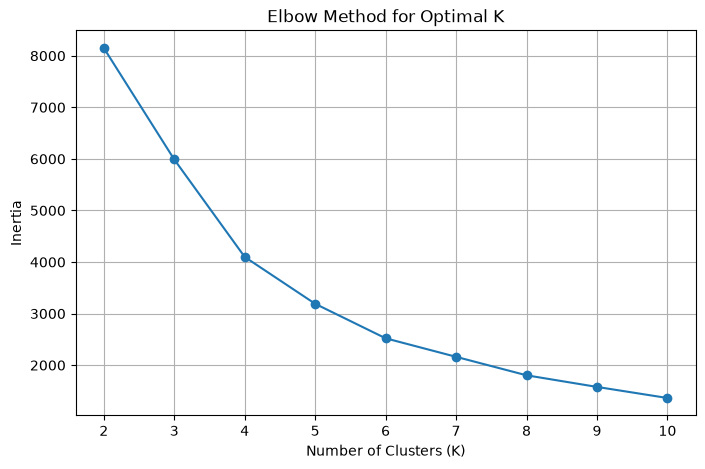

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.grid(True)

plt.savefig(
    "../results/figures/elbow_method.png",
    bbox_inches="tight"
)

plt.show()

In [9]:
silhouette_scores = []

for k in range(2, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster)
    
    score = silhouette_score(
        X_cluster,
        labels
    )
    
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "Number of Clusters": range(2, 11),
    "Silhouette Score": silhouette_scores
})

silhouette_results

,Number of Clusters,Silhouette Score
0,2,0.565597
1,3,0.569511
2,4,0.579816
3,5,0.612579
4,6,0.620674
5,7,0.621293
6,8,0.603025
7,9,0.613086
8,10,0.614854


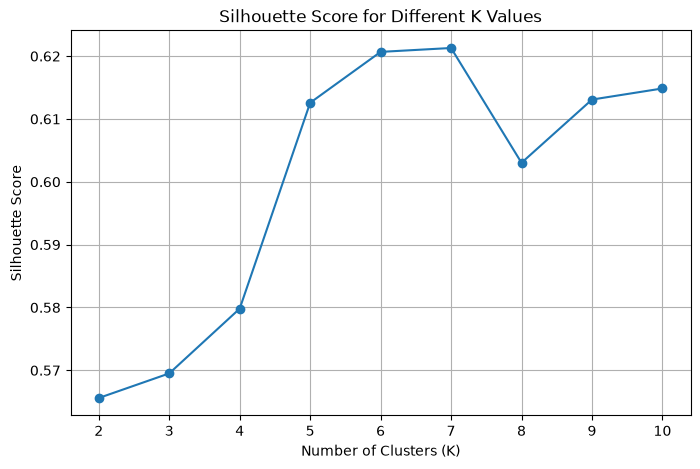

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.grid(True)

plt.savefig(
    "../results/figures/silhouette_score.png",
    bbox_inches="tight"
)

plt.show()

In [12]:
best_k = 3   

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(
    X_cluster
)

cluster_data["Cluster"] = cluster_labels

print("K-Means clustering completed!")

K-Means clustering completed!


In [13]:
cluster_summary = cluster_data.groupby(
    "Cluster"
)[
    [
        "area_sqft",
        "bedroom",
        "bathroom",
        "parking",
        "price"
    ]
].mean()

cluster_summary

,area_sqft,bedroom,bathroom,parking,price
Cluster,,,,,
0,6.761055e+03,0.523883,0.298921,0.192604,5.815583e+11
1,3.428420e+03,6.092700,4.232908,2.213210,3.503064e+07
2,3.802778e+14,1.000000,1.000000,1.000000,2.000000e+04


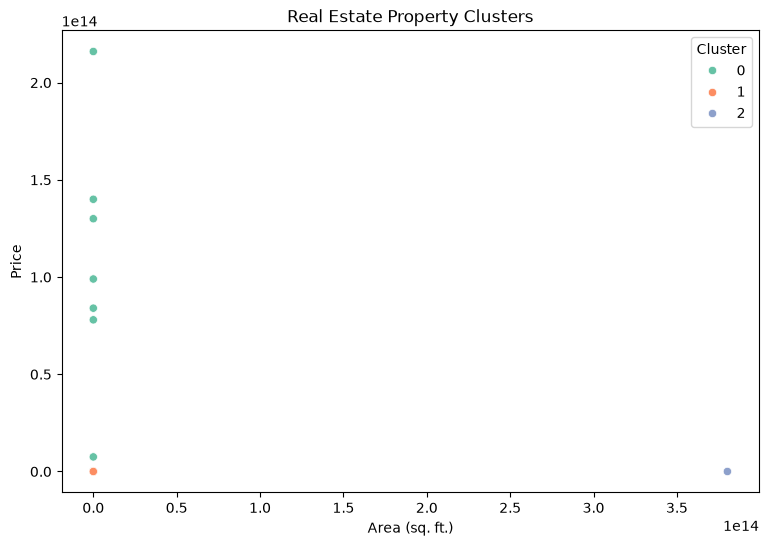

In [14]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=cluster_data,
    x="area_sqft",
    y="price",
    hue="Cluster",
    palette="Set2"
)

plt.title("Real Estate Property Clusters")
plt.xlabel("Area (sq. ft.)")
plt.ylabel("Price")

plt.savefig(
    "../results/figures/property_clusters.png",
    bbox_inches="tight"
)

plt.show()

In [15]:
elbow_results = pd.DataFrame({
    "K": list(K),
    "Inertia": inertia
})

print(elbow_results.to_string(index=False))

 K     Inertia
 2 8150.410644
 3 5988.822856
 4 4098.900486
 5 3190.153274
 6 2521.274971
 7 2161.979582
 8 1803.760124
 9 1578.368644
10 1363.502751


In [16]:
print(silhouette_results.to_string(index=False))

 Number of Clusters  Silhouette Score
                  2          0.565597
                  3          0.569511
                  4          0.579816
                  5          0.612579
                  6          0.620674
                  7          0.621293
                  8          0.603025
                  9          0.613086
                 10          0.614854


In [17]:
best_k = 7

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_cluster)

cluster_data["Cluster"] = cluster_labels

print("K-Means clustering completed!")
print("Number of clusters:", best_k)

K-Means clustering completed!
Number of clusters: 7


In [18]:
cluster_counts = cluster_data["Cluster"].value_counts().sort_index()

print("Properties in each cluster:")
print(cluster_counts)

Properties in each cluster:
Cluster
0     864
1    1238
2       1
3      40
4       1
5       6
6      12
Name: count, dtype: int64


In [19]:
cluster_summary = cluster_data.groupby("Cluster")[
    [
        "area_sqft",
        "bedroom",
        "bathroom",
        "parking",
        "price"
    ]
].mean().round(2)

cluster_summary

,area_sqft,bedroom,bathroom,parking,price
Cluster,,,,,
0,2.971110e+03,5.61,3.88,1.70,3.220995e+07
1,7.009340e+03,0.38,0.22,0.17,6.350577e+09
2,3.802778e+14,1.00,1.00,1.00,2.000000e+04
3,1.061409e+04,6.10,4.95,11.32,5.759900e+07
4,7.187250e+03,95.00,40.00,7.00,1.450000e+08
5,1.561520e+03,0.33,0.17,0.17,1.245000e+14
6,4.071280e+03,23.08,14.83,1.58,5.150375e+07


In [20]:
cluster_data.to_csv(
    "../data/processed/clustered_properties.csv",
    index=False
)

print("Clustered dataset saved successfully!")

Clustered dataset saved successfully!


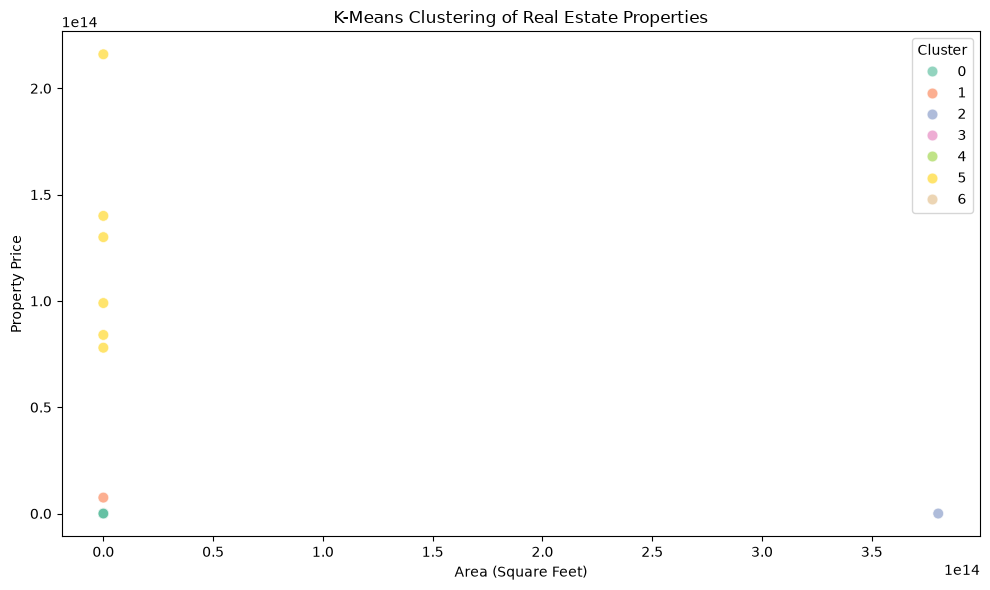

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=cluster_data,
    x="area_sqft",
    y="price",
    hue="Cluster",
    palette="Set2",
    s=60,
    alpha=0.7
)

plt.title("K-Means Clustering of Real Estate Properties")
plt.xlabel("Area (Square Feet)")
plt.ylabel("Property Price")
plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(
    "../results/figures/kmeans_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

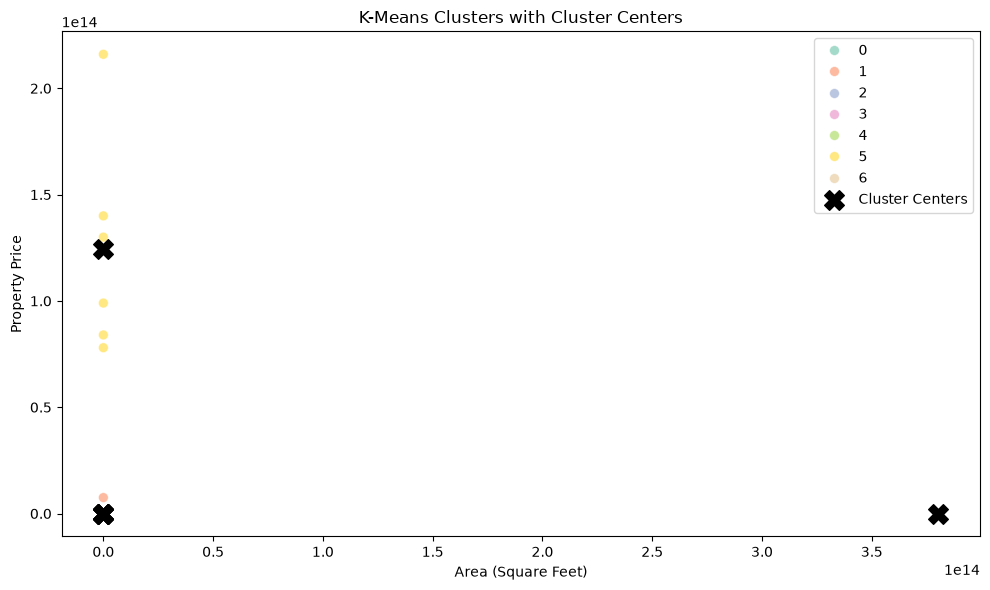

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=cluster_data,
    x="area_sqft",
    y="price",
    hue="Cluster",
    palette="Set2",
    s=50,
    alpha=0.6
)

centers_original = scaler.inverse_transform(
    final_kmeans.cluster_centers_
)

centers_df = pd.DataFrame(
    centers_original,
    columns=cluster_features
)

plt.scatter(
    centers_df["area_sqft"],
    centers_df["price"],
    marker="X",
    s=200,
    color="black",
    label="Cluster Centers"
)

plt.title("K-Means Clusters with Cluster Centers")
plt.xlabel("Area (Square Feet)")
plt.ylabel("Property Price")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/kmeans_cluster_centers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
cluster_summary = cluster_data.groupby("Cluster")[
    [
        "area_sqft",
        "bedroom",
        "bathroom",
        "parking",
        "price"
    ]
].agg(["count", "mean", "min", "max"]).round(2)

cluster_summary

area_sqft                                           bedroom         \
            count          mean           min           max   count   mean   
Cluster                                                                      
0             864  2.971110e+03  0.000000e+00  2.395750e+05     864   5.61   
1            1238  7.009340e+03  0.000000e+00  4.380800e+05    1238   0.38   
2               1  3.802778e+14  3.802778e+14  3.802778e+14       1   1.00   
3              40  1.061409e+04  2.000000e+01  7.666400e+04      40   6.10   
4               1  7.187250e+03  7.187250e+03  7.187250e+03       1  95.00   
5               6  1.561520e+03  7.272800e+02  2.823560e+03       6   0.33   
6              12  4.071280e+03  8.556200e+02  1.095200e+04      12  23.08   

                bathroom                parking                price  \
        min max    count   mean min max   count   mean min max count   
Cluster                                                                
0         0  28      864   3.88   0  10     864   1.70   0   6   864   
1         0   7     1238   0.22   0   4    1238   0.17   0   6  1238   
2         1   1        1   1.00   1   1       1   1.00   1   1     1   
3         0  24       40   4.95   0  15      40  11.32   7  31    40   
4        95  95        1  40.00  40  40       1   7.00   7   7     1   
5         0   2        6   0.17   0   1       6   0.17   0   1     6   
6        16  43       12  14.83   0  22      12   1.58   0   4    12   

                                                        
                 mean             min              max  
Cluster                                                 
0        3.220995e+07             240       2000000025  
1        6.350577e+09              15    7500000750000  
2        2.000000e+04           20000            20000  
3        5.759900e+07             100        250000000  
4        1.450000e+08       145000000        145000000  
5        1.245000e+14  78000001300000  216000002700000  
6        5.150375e+07          125000        142500000

In [24]:
cluster_data.groupby("Cluster")["price"].agg(
    ["count", "min", "max", "mean", "median"]
).round(2)

,count,min,max,mean,median
Cluster,,,,,
0,864,240,2000000025,3.220995e+07,2.500000e+07
1,1238,15,7500000750000,6.350577e+09,2.800000e+06
2,1,20000,20000,2.000000e+04,2.000000e+04
3,40,100,250000000,5.759900e+07,4.250000e+07
4,1,145000000,145000000,1.450000e+08,1.450000e+08
5,6,78000001300000,216000002700000,1.245000e+14,1.145000e+14
6,12,125000,142500000,5.150375e+07,3.800000e+07


In [25]:
cluster_data.groupby("Cluster")["area_sqft"].agg(
    ["count", "min", "max", "mean", "median"]
).round(2)

,count,min,max,mean,median
Cluster,,,,,
0,864,0.000000e+00,2.395750e+05,2.971110e+03,1.711250e+03
1,1238,0.000000e+00,4.380800e+05,7.009340e+03,1.818200e+03
2,1,3.802778e+14,3.802778e+14,3.802778e+14,3.802778e+14
3,40,2.000000e+01,7.666400e+04,1.061409e+04,7.016120e+03
4,1,7.187250e+03,7.187250e+03,7.187250e+03,7.187250e+03
5,6,7.272800e+02,2.823560e+03,1.561520e+03,1.369000e+03
6,12,8.556200e+02,1.095200e+04,4.071280e+03,2.310190e+03


In [26]:
print("Area statistics:")
print(data["area_sqft"].describe())

print("\nPrice statistics:")
print(data["price"].describe())

Area statistics:
count    2.162000e+03
mean     1.758917e+11
std      8.178490e+12
min      0.000000e+00
25%      1.245242e+03
50%      1.711355e+03
75%      3.422500e+03
max      3.802778e+14
Name: area_sqft, dtype: float64

Price statistics:
count    2.211000e+03
mean     4.064428e+11
std      7.564269e+12
min      1.500000e+01
25%      1.300000e+06
50%      8.000000e+06
75%      2.650000e+07
max      2.160000e+14
Name: price, dtype: float64


In [27]:
print("Largest Area values:")
print(
    data["area_sqft"]
    .sort_values(ascending=False)
    .head(20)
)

print("\nLargest Price values:")
print(
    data["price"]
    .sort_values(ascending=False)
    .head(20)
)

Largest Area values:
166     3.802778e+14
1911    4.380800e+05
2131    3.011800e+05
293     2.884740e+05
1040    2.738000e+05
1519    2.395750e+05
1441    2.190400e+05
2126    2.190400e+05
232     2.187000e+05
1053    1.642800e+05
579     1.642800e+05
725     1.106152e+05
480     1.102045e+05
1264    1.093500e+05
424     1.088013e+05
1916    9.477000e+04
292     8.898500e+04
1013    8.556250e+04
1707    7.666400e+04
1400    7.500000e+04
Name: area_sqft, dtype: float64

Largest Price values:
1664    216000002700000
1767    143750001250000
1678    140000003500000
1651    130000004000000
1550     99000003300000
1614     84000002100000
1615     78000001300000
1566      7500000750000
1607       190000150000
1538       155000150000
1675         2000000025
1571         1800000020
1696         1500000015
1602          850000017
1795          605000055
2124          600000000
521           500000000
769           400000000
2130          350000000
647           300000000
Name: price, dtype: int6

In [28]:
cluster_clean = data[
    (data["area_sqft"] > 0) &
    (data["area_sqft"] <= 100000) &
    (data["price"] > 0) &
    (data["price"] <= 500000000)
].copy()

print("Original rows:", len(data))
print("After outlier filtering:", len(cluster_clean))

Original rows: 2211
After outlier filtering: 2131


In [29]:
cluster_features = [
    "area_sqft",
    "bedroom",
    "bathroom",
    "parking",
    "price"
]

cluster_data = cluster_clean[cluster_features].dropna().copy()

print("Clustering data shape:", cluster_data.shape)

Clustering data shape: (2131, 5)


In [30]:
scaler = StandardScaler()

X_cluster = scaler.fit_transform(cluster_data)

print("Feature scaling completed!")

Feature scaling completed!


In [31]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

elbow_results = pd.DataFrame({
    "K": range(2, 11),
    "Inertia": inertia
})

print(elbow_results.to_string(index=False))

 K     Inertia
 2 7699.669504
 3 6197.217093
 4 5141.430321
 5 4467.220525
 6 3894.402837
 7 3492.200572
 8 3140.851119
 9 2895.326471
10 2649.433662


In [32]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster)
    
    score = silhouette_score(
        X_cluster,
        labels
    )
    
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "K": range(2, 11),
    "Silhouette Score": silhouette_scores
})

print(silhouette_results.to_string(index=False))

 K  Silhouette Score
 2          0.431137
 3          0.455361
 4          0.467175
 5          0.473295
 6          0.487375
 7          0.439660
 8          0.446080
 9          0.454390
10          0.466480


In [33]:
best_k = 6

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_cluster)

cluster_data["Cluster"] = cluster_labels

print("K-Means clustering completed!")
print("Best number of clusters:", best_k)

K-Means clustering completed!
Best number of clusters: 6


In [34]:
cluster_counts = (
    cluster_data["Cluster"]
    .value_counts()
    .sort_index()
)

print("Properties in each cluster:")
print(cluster_counts)

Properties in each cluster:
Cluster
0     833
1    1178
2      32
3      40
4      11
5      37
Name: count, dtype: int64


In [35]:
cluster_summary = cluster_data.groupby("Cluster")[
    [
        "area_sqft",
        "bedroom",
        "bathroom",
        "parking",
        "price"
    ]
].agg(
    ["count", "mean", "median"]
).round(2)

cluster_summary

area_sqft                     bedroom               bathroom         \
            count      mean    median   count   mean median    count   mean   
Cluster                                                                       
0             833   2410.68   1711.25     833   5.65    5.0      833   3.87   
1            1178   3167.55   1711.25    1178   0.43    0.0     1178   0.25   
2              32   9612.28   7016.12      32   3.56    4.0       32   3.62   
3              40  55536.30  52895.00      40   0.62    0.0       40   0.18   
4              11   4562.74   2224.62      11  30.82   23.0       11  18.00   
5              37  10753.19   6845.00      37   6.08    6.0       37   4.97   

               parking               price                             
        median   count   mean median count          mean       median  
Cluster                                                                
0          4.0     833   1.69    1.0   833  2.823769e+07   25000000.0  
1          0.0    1178   0.18    0.0  1178  7.754647e+06    2700000.0  
2          4.0      32   1.97    0.0    32  1.811250e+08  150000000.0  
3          0.0      40   0.15    0.0    40  6.427252e+06    1300000.0  
4         18.0      11   2.00    1.0    11  5.836773e+07   35000000.0  
5          4.0      37  11.59   10.0    37  5.172054e+07   35000000.0

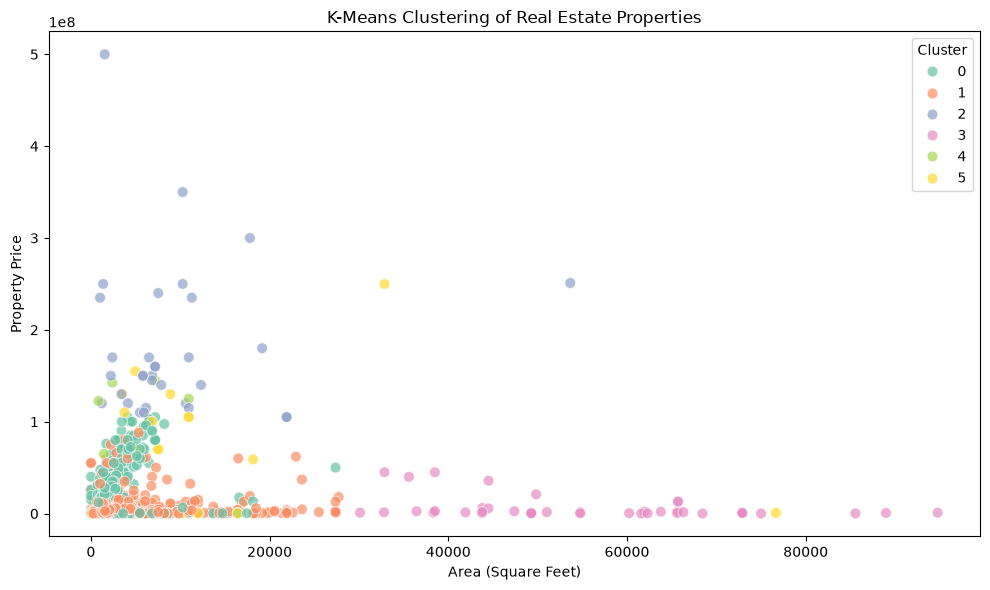

In [36]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=cluster_data,
    x="area_sqft",
    y="price",
    hue="Cluster",
    palette="Set2",
    s=60,
    alpha=0.7
)

plt.title("K-Means Clustering of Real Estate Properties")
plt.xlabel("Area (Square Feet)")
plt.ylabel("Property Price")
plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(
    "../results/figures/kmeans_clusters_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
cluster_data.to_csv(
    "../data/processed/clustered_properties.csv",
    index=False
)

print("Final clustered dataset saved successfully!")

Final clustered dataset saved successfully!


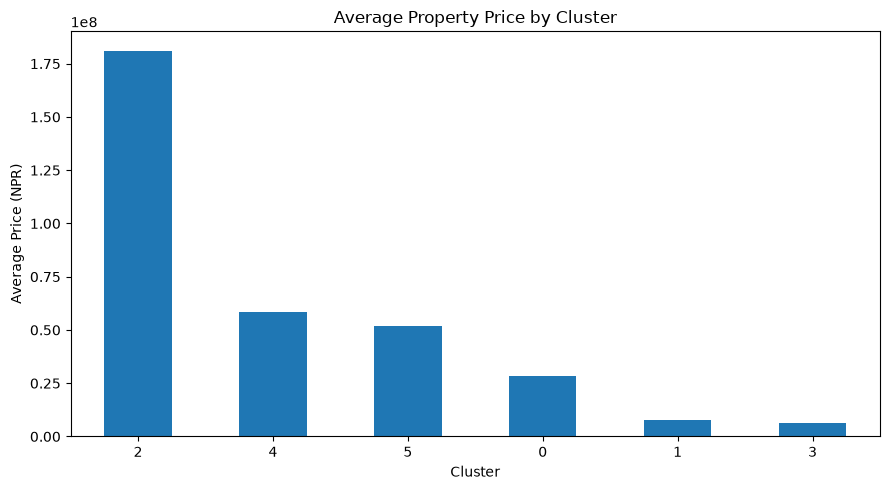

In [38]:
cluster_price = (
    cluster_data.groupby("Cluster")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

cluster_price.plot(kind="bar")

plt.title("Average Property Price by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Price (NPR)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../results/figures/average_price_by_cluster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

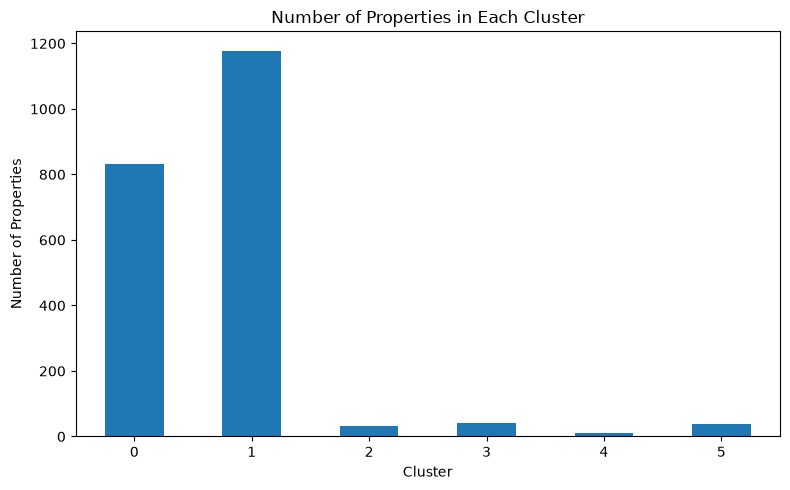

In [39]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind="bar")

plt.title("Number of Properties in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Properties")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../results/figures/cluster_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()